In [2]:
!pip install librosa scipy matplotlib numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Лабораторная 6

# _____________________________________________________________________

#### Подключение библиотек

In [3]:
import warnings
warnings.simplefilter(action="ignore", category=(FutureWarning, DeprecationWarning))
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import yfinance as yf

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

def fetch_data(ticker, period=None, start=None, end=None):
    data = yf.Ticker(ticker)
    df = data.history(period=period, start=start, end=end)
    return df

def run_adf(series, label, reg_type):
    res = adfuller(series, regression=reg_type)
    print(f"Результаты для {label}:")
    print(f"  ADF-статистика: {res[0]:.2f}")
    print(f"  p-значение: {res[1]:.3f}")
    crit = ", ".join([f"{k}: {v:.2f}" for v, k in zip(res[4].values(), res[4].keys())])
    print(f"  Критические: {crit}\n")

def calc_hurst(ts):
    lags = range(2, 100)
    tau = [np.var(np.subtract(ts[lag:], ts[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] / 2.0

#### Шаг 1: Загрузка и визуализация данных

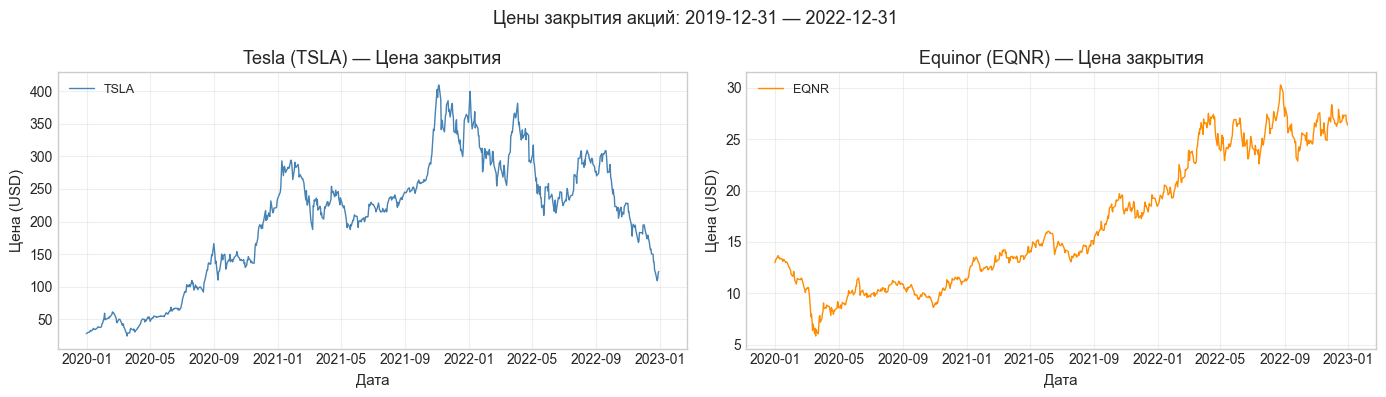

In [4]:
tsla = fetch_data("TSLA", period=None, start="2019-12-31", end="2022-12-31")
eqnr = fetch_data("EQNR", period=None, start="2019-12-31", end="2022-12-31")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(tsla["Close"], color="steelblue", linewidth=1.0)
axes[0].set_title("Tesla (TSLA) — Цена закрытия", fontsize=13)
axes[0].set_xlabel("Дата", fontsize=11)
axes[0].set_ylabel("Цена (USD)", fontsize=11)
axes[0].legend(["TSLA"], loc="upper left", fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(eqnr["Close"], color="darkorange", linewidth=1.0)
axes[1].set_title("Equinor (EQNR) — Цена закрытия", fontsize=13)
axes[1].set_xlabel("Дата", fontsize=11)
axes[1].set_ylabel("Цена (USD)", fontsize=11)
axes[1].legend(["EQNR"], loc="upper left", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Цены закрытия акций: 2019-12-31 — 2022-12-31", fontsize=13)
plt.tight_layout()
plt.show()

TSLA демонстрирует сильный восходящий тренд с последующим резким падением. Ряд нестационарен — среднее и дисперсия меняются со временем.

EQNR показывает более плавный восходящий тренд без резких скачков. Тренд устойчив, но ряд также нестационарен.

#### Шаг 2: Тест на единичный корень (ADF)

In [5]:
run_adf(tsla["Close"], "Tesla (TSLA)", "ct")
run_adf(eqnr["Close"], "Equinor (EQNR)", "ct")

Результаты для Tesla (TSLA):
  ADF-статистика: -0.93
  p-значение: 0.953
  Критические: 1%: -3.97, 5%: -3.42, 10%: -3.13

Результаты для Equinor (EQNR):
  ADF-статистика: -3.60
  p-значение: 0.030
  Критические: 1%: -3.97, 5%: -3.42, 10%: -3.13



TSLA: ADF = -0.93, p-value = 0.953. Гипотеза о нестационарности не отвергается. Ряд содержит единичный корень.

EQNR: ADF = -3.60, p-value = 0.030. Статистика пересекает критическое значение на уровне 5%. Формально ряд стационарен относительно тренда.

#### Шаг 3: Показатель Херста

In [10]:
h_tsla = calc_hurst(tsla["Close"].values)
h_eqnr = calc_hurst(eqnr["Close"].values)

def interpret_hurst(h):
    if h < 0.45:
        return "Возврат к среднему (H < 0.5)"
    elif h > 0.55:
        return "Трендовый (H > 0.5)"
    else:
        return "Близко к случайному блужданию (H ~ 0.5)"

print(f"TSLA показатель Херста: {h_tsla:.4f} : {interpret_hurst(h_tsla)}")
print(f"EQNR показатель Херста: {h_eqnr:.4f} : {interpret_hurst(h_eqnr)}")

TSLA показатель Херста: 0.4626 : Близко к случайному блужданию (H ~ 0.5)
EQNR показатель Херста: 0.3316 : Возврат к среднему (H < 0.5)


TSLA: H ~ 0.5 на границе случайного блуждания. Прошлые движения цены практически не влияют на будущие.

EQNR: H = 0.33 явный возврат к среднему. Цена исторически возвращается к среднему уровню.

#### Шаг 4: Инвестиционное решение

Нуууу визуально EQNR привлекательнее стабильный тренд без резких просадок.

На основе ADF и Херста:

EQNR ряд с возвратом к среднему. После сильного падения цена возвращалась вверх. ADF подтверждает наличие структуры и предсказуемости.

TSLA случайное блуждание. ADF не отвергает единичный корень. Исторические паттерны не дают преимущества.

#### Шаг 5: Моделирование GBM

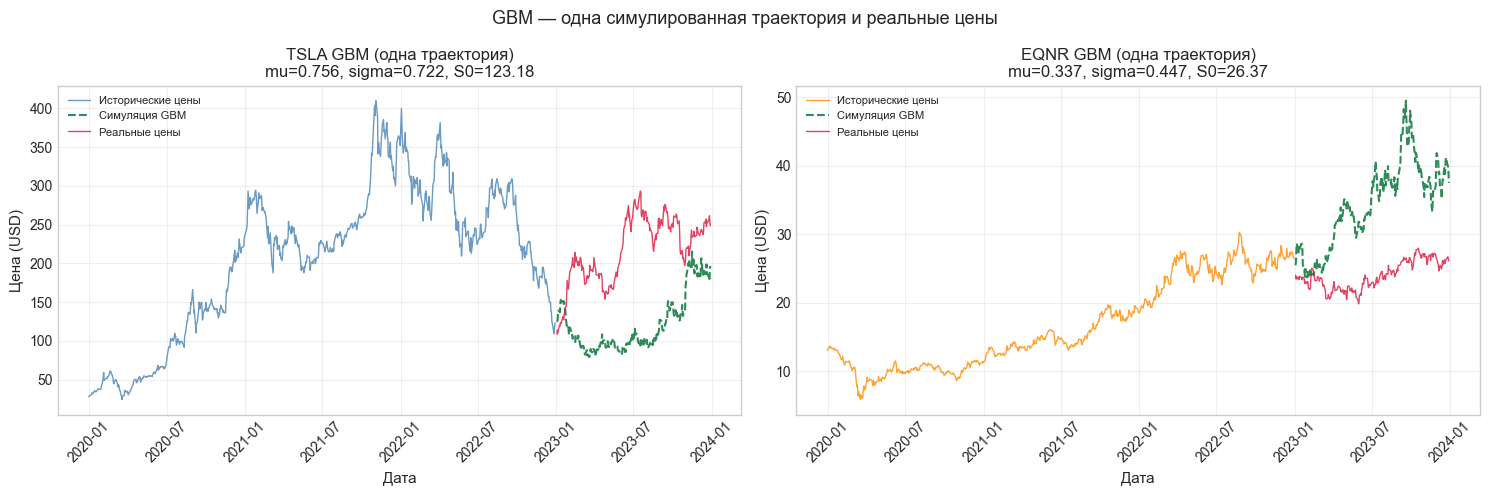

In [7]:
np.random.seed(42)
tsla_test = fetch_data("TSLA", period=None, start="2022-12-31", end="2023-12-31")
eqnr_test = fetch_data("EQNR", period=None, start="2022-12-31", end="2023-12-31")

def gbm_single(train_close, test_days):
    ret = train_close.pct_change().dropna()
    mu    = ret.mean() * 252
    sigma = ret.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    dt    = 1 / test_days
    N     = test_days
    t_step = np.linspace(0, 1, N)
    W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
    X = (mu - 0.5 * sigma**2) * t_step + sigma * W
    return S0 * np.exp(X), mu, sigma, S0

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (ticker, train, test, color) in zip(axes, [
    ("TSLA", tsla, tsla_test, "steelblue"),
    ("EQNR", eqnr, eqnr_test, "darkorange")
]):
    S, mu, sigma, S0 = gbm_single(train["Close"], len(test))
    ax.plot(train["Close"], label="Исторические цены", color=color, alpha=0.8, linewidth=1.0)
    ax.plot(test.index, S, label="Симуляция GBM", color="seagreen", linestyle="--", linewidth=1.5)
    ax.plot(test["Close"], label="Реальные цены", color="crimson", alpha=0.8, linewidth=1.0)
    ax.set_title(f"{ticker} GBM (одна траектория)\nmu={mu:.3f}, sigma={sigma:.3f}, S0={S0:.2f}", fontsize=12)
    ax.set_xlabel("Дата", fontsize=11)
    ax.set_ylabel("Цена (USD)", fontsize=11)
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle("GBM — одна симулированная траектория и реальные цены", fontsize=13)
plt.tight_layout()
plt.show()

mu дрейф, ожидаемая годовая доходность. sigma волатильность. S0 начальная цена.

Траектория GBM для TSLA выглядит неправдоподобно резкий скачок. Для EQNR симуляция ближе к реальности.

#### Шаг 6: Множественные симуляции GBM

Множество путей формируют вероятностное распределение возможных будущих цен. Доверительный интервал показывает диапазон ожидаемых значений.

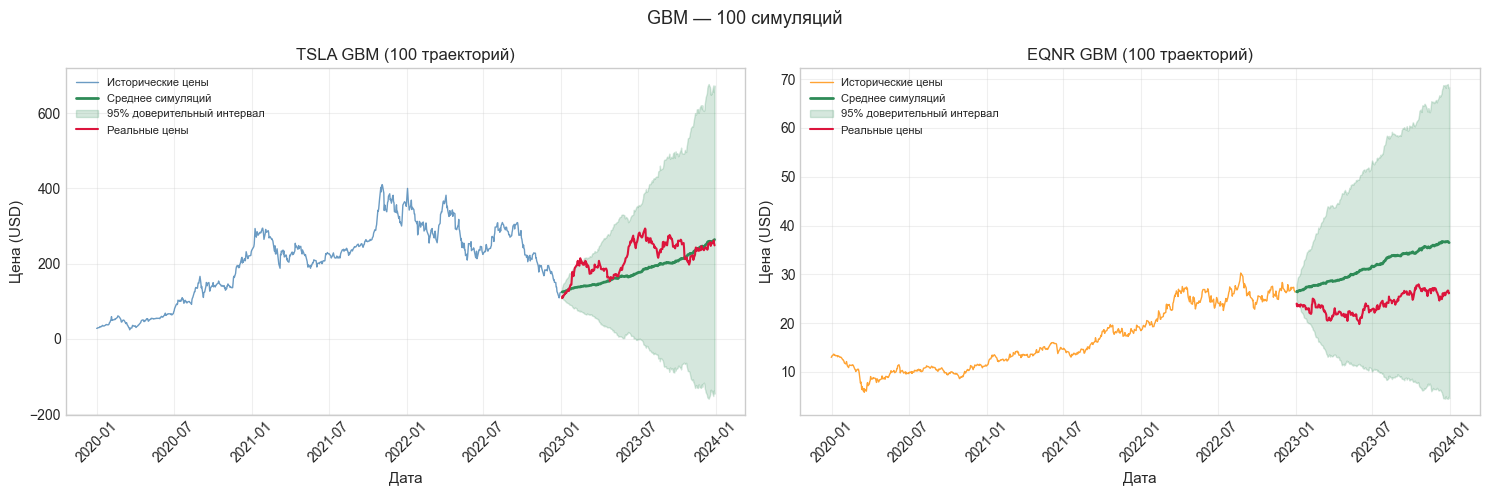

In [8]:
n_paths = 100

def gbm_multi(train_close, test_days, n):
    ret = train_close.pct_change().dropna()
    mu    = ret.mean() * 252
    sigma = ret.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    dt    = 1 / test_days
    N     = test_days
    t_step = np.linspace(0, 1, N)
    paths = []
    for _ in range(n):
        W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * t_step + sigma * W
        paths.append(S0 * np.exp(X))
    paths = np.array(paths)
    return paths, paths.mean(axis=0), paths.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (ticker, train, test, color) in zip(axes, [
    ("TSLA", tsla, tsla_test, "steelblue"),
    ("EQNR", eqnr, eqnr_test, "darkorange")
]):
    paths, p_mean, p_std = gbm_multi(train["Close"], len(test), n_paths)
    lower = p_mean - 1.96 * p_std
    upper = p_mean + 1.96 * p_std

    ax.plot(train["Close"], label="Исторические цены", color=color, alpha=0.8, linewidth=1.0)
    ax.plot(test.index, p_mean, label="Среднее симуляций", color="seagreen", linewidth=2)
    ax.fill_between(test.index, lower, upper, alpha=0.2, color="seagreen", label="95% доверительный интервал")
    ax.plot(test["Close"], label="Реальные цены", color="crimson", linewidth=1.5)
    ax.set_title(f"{ticker} GBM ({n_paths} траекторий)", fontsize=12)
    ax.set_xlabel("Дата", fontsize=11)
    ax.set_ylabel("Цена (USD)", fontsize=11)
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"GBM — {n_paths} симуляций", fontsize=13)
plt.tight_layout()
plt.show()

Для TSLA доверительный интервал очень широкий от -100 до 600. Попадает любое поведение цены.

Для EQNR ситуация лучше. Красная линия идёт внутри интервала и держится близко к среднему. Интервал значительно уже.

#### Шаг 7: MSE и MAPE оценка качества

Измеряем среднюю ошибку

In [9]:
np.random.seed(42)

def compute_metrics(train_close, test_close, n_paths=100):
    ret = train_close.pct_change().dropna()
    mu    = ret.mean() * 252
    sigma = ret.std() * np.sqrt(252)
    S0    = train_close.iloc[-1]
    test_days = len(test_close)
    dt    = 1 / test_days
    N     = test_days
    t_step = np.linspace(0, 1, N)
    real = test_close.values

    mse_list, mape_list = [], []
    for _ in range(n_paths):
        W = np.cumsum(np.random.standard_normal(size=N)) * np.sqrt(dt)
        X = (mu - 0.5 * sigma**2) * t_step + sigma * W
        sim = S0 * np.exp(X)
        mse_list.append(np.mean((real - sim) ** 2))
        mape_list.append(np.mean(np.abs(real - sim) / np.abs(real)) * 100)

    return np.mean(mse_list), np.mean(mape_list)

e_mse_tsla, e_mape_tsla = compute_metrics(tsla["Close"], tsla_test["Close"])
e_mse_eqnr, e_mape_eqnr = compute_metrics(eqnr["Close"], eqnr_test["Close"])

results_df = pd.DataFrame({
    "Актив":    ["TSLA (Tesla)", "EQNR (Equinor)"],
    "E[MSE]":   [f"{e_mse_tsla:.2f}", f"{e_mse_eqnr:.2f}"],
    "E[MAPE], %": [f"{e_mape_tsla:.2f}%", f"{e_mape_eqnr:.2f}%"]
})
print(results_df.to_string(index=False))

         Актив   E[MSE] E[MAPE], %
  TSLA (Tesla) 15817.38     39.78%
EQNR (Equinor)   187.59     39.89%


TSLA: в среднем симуляция ошибается на 41% от реальной цены. MSE огромен из-за квадратичного масштаба и большого разброса траекторий.

EQNR: симуляция ошибается на 37%, чуть лучше TSLA. MSE на два порядка меньше.

EQNR моделируется надёжнее по обоим метрикам. Разница в MSE 100 раз. MAPE отличается меньше (41%/37%).